# AI: Fundamentals and Applications
## Practical Work 1 — Iris flower classification

**Level:** bachelor students  
**Lesson:** 1  
**Time:** 2 hours  
**Difficulty:** beginner  
**Dataset:** Iris flowers

In this work I build my first machine-learning model. No advanced mathematics is needed here.

### Learning outcomes

After finishing this notebook I am able to:

1. explain the terms *example*, *feature*, *label*, *training*, *prediction* and *accuracy*;
2. describe a small dataset with numbers and plots;
3. split the data into a training part and a testing part;
4. train a k-nearest-neighbours classifier;
5. predict the species of flowers the model has never seen;
6. measure the quality of the answers with accuracy and a confusion matrix;
7. explain why a good score is not the same thing as a trustworthy model.

## 1. What is the task for the computer?

The dataset stores four measurements for every Iris flower. Every flower belongs to one of three species:

- **setosa**;
- **versicolor**;
- **virginica**.

The computer receives the four numbers and has to name the species. The answer is one of three
fixed options, so the task is **classification** (not a prediction of a continuous number).

| AI term | What it means in this notebook |
|---|---|
| Example | A single flower (one row of the table) |
| Feature | One measurement of that flower (one column) |
| Label | The true species of the flower |
| Training | The model studies flowers whose species is already known |
| Prediction | The answer the model gives for a flower |
| Classification | Choosing one category out of several categories |

The training examples come together with their correct labels, therefore this is
**supervised learning**.

### Checkpoint 1

**Example** — one flower, described by one row of four numbers.  
**Feature** — one input measurement. I have four of them: sepal length, sepal width, petal length, petal width.  
**Label** — the correct answer I want the model to reproduce, that is the species.  
**Training** — the step where the model extracts patterns from flowers with known labels.  
**Prediction** — the species the trained model assigns to a flower.  
**Accuracy** — the share of predictions that turned out to be correct.  
**Classification** — the type of task: the output is a category, not a number.

## 2. Import the tools

I import the libraries first, so the rest of the notebook can focus on the AI steps.
I do not implement the learning algorithm from formulas in this lesson.

`SEED` is a fixed number for every random operation. Thanks to it the notebook gives the same
result on every run, and the results can be checked by another person.

In [1]:
%matplotlib inline

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

SEED = 42
sns.set_theme(style="whitegrid")

print("Libraries are ready. Random seed =", SEED)

Libraries are ready. Random seed = 42


## 3. Load the dataset

`features` holds the four input columns, `labels` holds the correct species encoded as
numbers 0, 1 and 2.

| Column index | Measurement |
|---|---|
| 0 | Sepal length |
| 1 | Sepal width |
| 2 | Petal length |
| 3 | Petal width |

A sepal is the green leaf under the flower, a petal is the coloured part of the flower.

In [2]:
iris_data = load_iris()

features = iris_data.data
labels = iris_data.target
species_names = iris_data.target_names
feature_names = iris_data.feature_names

print("Flowers in the dataset :", features.shape[0])
print("Measurements per flower:", features.shape[1])
print("Species names          :", list(species_names))
print("Feature names          :", feature_names)
print("features.shape         :", features.shape)
print("labels.shape           :", labels.shape)

Flowers in the dataset : 150
Measurements per flower: 4
Species names          : [np.str_('setosa'), np.str_('versicolor'), np.str_('virginica')]
Feature names          : ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']
features.shape         : (150, 4)
labels.shape           : (150,)


**Reading the shapes**

- `features.shape` is `(150, 4)`: 150 flowers in the rows, 4 measurements in the columns.
- `labels.shape` is `(150,)`: one single correct answer per flower, so only one dimension.

The label is a number, not a word, because the algorithms work with numbers.
`species_names` is the translation table: 0 &rarr; setosa, 1 &rarr; versicolor, 2 &rarr; virginica.

In [3]:
# The first eight rows of the raw feature matrix.
features[:8]

array([[5.1, 3.5, 1.4, 0.2],
       [4.9, 3. , 1.4, 0.2],
       [4.7, 3.2, 1.3, 0.2],
       [4.6, 3.1, 1.5, 0.2],
       [5. , 3.6, 1.4, 0.2],
       [5.4, 3.9, 1.7, 0.4],
       [4.6, 3.4, 1.4, 0.3],
       [5. , 3.4, 1.5, 0.2]])

In [4]:
# The label of every flower. The dataset is sorted by species.
labels

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2])

In [5]:
iris_table = pd.DataFrame(features, columns=feature_names)
iris_table["species"] = species_names[labels]

print("Table shape:", iris_table.shape)
display(iris_table.head(10))
display(iris_table.describe().round(2))

Table shape: (150, 5)


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa
5,5.4,3.9,1.7,0.4,setosa
6,4.6,3.4,1.4,0.3,setosa
7,5.0,3.4,1.5,0.2,setosa
8,4.4,2.9,1.4,0.2,setosa
9,4.9,3.1,1.5,0.1,setosa


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
count,150.00,150.00,150.00,150.00
mean,5.84,3.06,3.76,1.20
std,0.83,0.44,1.77,0.76
min,4.30,2.00,1.00,0.10
25%,5.10,2.80,1.60,0.30
50%,5.80,3.00,4.35,1.30
75%,6.40,3.30,5.10,1.80
max,7.90,4.40,6.90,2.50


## 4. Explore the data

Before training anything I look at the data itself. First I count the flowers of every species.
This tells me whether the dataset is **balanced**.

species
setosa        50
versicolor    50
virginica     50
Name: count, dtype: int64

Share of each species:
species
setosa        0.333
versicolor    0.333
virginica     0.333
Name: count, dtype: float64


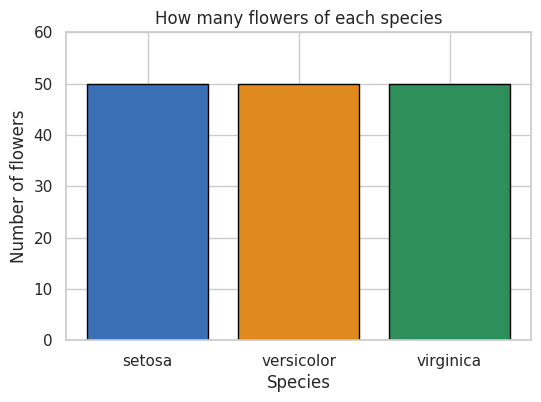

In [6]:
species_counts = iris_table["species"].value_counts().sort_index()
print(species_counts)
print()
print("Share of each species:")
print((species_counts / len(iris_table)).round(3))

plt.figure(figsize=(6, 4))
plt.bar(species_counts.index, species_counts.values,
        color=["#3b6fb6", "#e08a1e", "#2f8f5b"], edgecolor="black")
plt.title("How many flowers of each species")
plt.xlabel("Species")
plt.ylabel("Number of flowers")
plt.ylim(0, 60)
plt.show()

Now I plot the flowers using two of the four measurements. Every point is one flower and the
colour shows its true species.

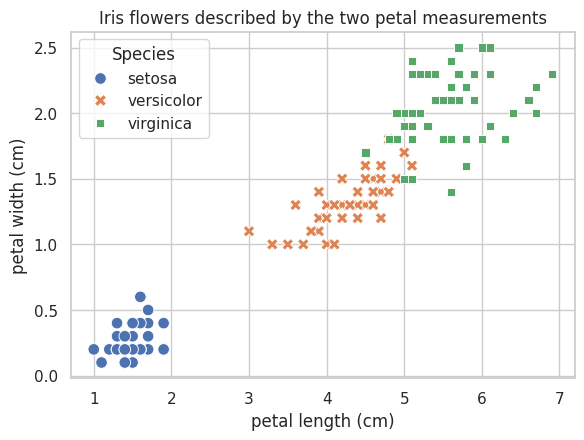

In [7]:
plt.figure(figsize=(6.5, 4.5))
sns.scatterplot(
    data=iris_table,
    x="petal length (cm)",
    y="petal width (cm)",
    hue="species",
    style="species",
    s=70,
)
plt.title("Iris flowers described by the two petal measurements")
plt.legend(title="Species")
plt.show()

The petal measurements separate the species well. For comparison I draw the same flowers using
the two **sepal** measurements, which are a much weaker signal.

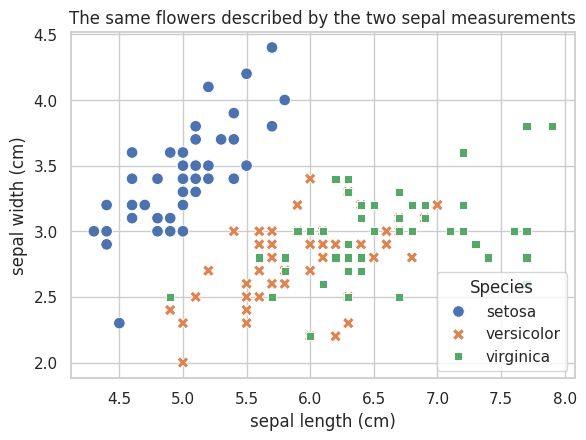

In [8]:
plt.figure(figsize=(6.5, 4.5))
sns.scatterplot(
    data=iris_table,
    x="sepal length (cm)",
    y="sepal width (cm)",
    hue="species",
    style="species",
    s=70,
)
plt.title("The same flowers described by the two sepal measurements")
plt.legend(title="Species")
plt.show()

### Checkpoint 2

**1. Is the dataset balanced? Explain using the class counts.**  
Yes, it is perfectly balanced. Each species appears exactly 50 times, so each one is 33.3% of the
150 flowers. No species can dominate the model only because it is more frequent, and accuracy is
a meaningful metric here.

**2. Which species is visually easiest to separate?**  
Setosa. In the petal plot its points form a group in the bottom-left corner with a clear empty gap
between it and the other two species: its petals are much shorter and narrower. A single threshold
on petal length would already isolate it.

**3. Do versicolor and virginica overlap?**  
Yes. Around petal length 4.8–5.1 cm the orange and green points are mixed, so some versicolor
flowers are physically larger than some virginica flowers.

**4. Why might overlapping classes cause prediction errors?**  
In the overlap region the nearest neighbours of a flower belong to both species at the same time.
The vote can then go to the wrong side. The features simply do not contain enough information to
draw a perfect border there, so the errors I see later are expected exactly in that pair.

## 5. Divide the data into a training set and a testing set

A model must never be evaluated on the same examples it learned from: it would only prove that it
can repeat what it has already seen.

- **Training set** — the examples the model learns the patterns from (80%, 120 flowers).
- **Testing set** — unseen examples kept aside to check the trained model (20%, 30 flowers).

Two arguments of `train_test_split` deserve attention:

- `random_state=SEED` fixes the shuffling, so the split is *reproducible*: the same rows go to the
  same side on every run.
- `stratify=labels` makes the split *representative*: instead of cutting the shuffled dataset in
  one place, the function takes 20% inside every species separately and then joins the pieces.
  That is why the printed counts are exactly `[40 40 40]` and `[10 10 10]`. Without it the
  proportions would be random, the test score would be biased towards whichever species happened
  to be over-represented, and the comparison between different settings of `k` would measure luck
  instead of quality. On an imbalanced dataset a rare class could even disappear from the test set
  completely.

In [9]:
train_features, test_features, train_labels, test_labels = train_test_split(
    features,
    labels,
    test_size=0.20,
    random_state=SEED,
    stratify=labels,
)

print("Training flowers:", len(train_features))
print("Testing flowers :", len(test_features))
print()

train_values, train_counts = np.unique(train_labels, return_counts=True)
test_values, test_counts = np.unique(test_labels, return_counts=True)

split_overview = pd.DataFrame({
    "species": species_names[train_values],
    "in training set": train_counts,
    "in testing set": test_counts,
})
display(split_overview)

Training flowers: 120
Testing flowers : 30



,species,in training set,in testing set
0,setosa,40,10
1,versicolor,40,10
2,virginica,40,10


## 6. Bring the features to a comparable scale

k-nearest-neighbours measures the **distance** between flowers. A measurement with larger numbers
would push the distance around more than the others and would silently become more important.

Standardization rewrites every column as `z = (x - mean) / std`, so afterwards each column has
mean 0 and standard deviation 1.

**The rule that must not be broken:** the mean and the standard deviation are learned from the
**training data only** (`fit_transform`), and the very same numbers are then applied to the test
data (`transform`). If the test data took part in `fit`, information from the test set would leak
into the preparation step and the final score would be too optimistic.

In [10]:
standardizer = StandardScaler()
train_scaled = standardizer.fit_transform(train_features)
test_scaled = standardizer.transform(test_features)

print("Means learned from the training set:", standardizer.mean_.round(3))
print("Std learned from the training set  :", standardizer.scale_.round(3))
print()
print("First training flower, original:", train_features[0])
print("First training flower, scaled  :", train_scaled[0].round(3))

Means learned from the training set: [5.842 3.048 3.77  1.205]
Std learned from the training set  : [0.837 0.447 1.761 0.759]

First training flower, original: [4.4 2.9 1.4 0.2]
First training flower, scaled  : [-1.722 -0.332 -1.346 -1.323]


## 7. Train the first model

I use **k-nearest neighbours (k-NN)**. For a new flower the algorithm:

1. computes the distance to every training flower;
2. keeps the `k` closest ones;
3. looks at their labels and returns the most frequent one — the neighbours "vote".

With `n_neighbors=3` the three closest training flowers decide the answer. An odd value of `k`
is preferred because it reduces the chance of a tie in the vote.

In [11]:
knn_classifier = KNeighborsClassifier(n_neighbors=3)
knn_classifier.fit(train_scaled, train_labels)

print("Training finished.")
print("Neighbours used for one vote:", knn_classifier.n_neighbors)
print("Examples memorised by the model:", knn_classifier.n_samples_fit_)

Training finished.
Neighbours used for one vote: 3
Examples memorised by the model: 120


`.fit()` is the training step. For k-NN this step is unusually cheap: the model simply stores the
training flowers with their labels. All the real work happens later, during `.predict()`, when the
distances are computed. This is why k-NN is called a *lazy* algorithm.

## 8. Make predictions

The model now labels the 30 test flowers. It has never seen any of them.

In [12]:
knn_predictions = knn_classifier.predict(test_scaled)

results_table = pd.DataFrame({
    "true species": species_names[test_labels],
    "predicted species": species_names[knn_predictions],
})
results_table["correct?"] = results_table["true species"] == results_table["predicted species"]

display(results_table)
print("Rows marked as wrong:")
display(results_table[~results_table["correct?"]])

,true species,predicted species,correct?
0,setosa,setosa,True
1,virginica,virginica,True
2,versicolor,versicolor,True
3,versicolor,versicolor,True
4,setosa,setosa,True
5,versicolor,versicolor,True
6,setosa,setosa,True
7,setosa,setosa,True
8,virginica,virginica,True
9,versicolor,versicolor,True


Rows marked as wrong:


,true species,predicted species,correct?
19,virginica,versicolor,False
23,virginica,versicolor,False


I can also ask the model about a single flower.

**Why `reshape(1, -1)`?** The model expects a two-dimensional table shaped
(number of examples, number of features). One flower is stored as a flat array of shape `(4,)`,
so I reshape it into `(1, 4)`: one row, four columns. The `-1` means "compute this size yourself".

In [13]:
chosen_index = 5

single_flower = test_scaled[chosen_index].reshape(1, -1)
print("Shape before reshape:", test_scaled[chosen_index].shape)
print("Shape after reshape :", single_flower.shape)
print()

single_prediction = knn_classifier.predict(single_flower)[0]
single_probabilities = knn_classifier.predict_proba(single_flower)[0]

print("Original measurements:", test_features[chosen_index])
print("True species         :", species_names[test_labels[chosen_index]])
print("Predicted species    :", species_names[single_prediction])
print("Votes of the 3 neighbours:")
for name, share in zip(species_names, single_probabilities):
    print("   {:<12} {:.0f} of 3".format(name, share * knn_classifier.n_neighbors))

Shape before reshape: (4,)
Shape after reshape : (1, 4)

Original measurements: [6.3 3.3 4.7 1.6]
True species         : versicolor
Predicted species    : versicolor
Votes of the 3 neighbours:
   setosa       0 of 3
   versicolor   2 of 3
   virginica    1 of 3


## 9. Evaluate the model

Accuracy is the share of correct answers:

$$\text{Accuracy} = \frac{\text{number of correct predictions}}{\text{total number of predictions}}$$

The classification report adds **precision** (how often an answer of this class was right) and
**recall** (how many flowers of this class were found), which accuracy alone hides.

In [14]:
knn_accuracy = accuracy_score(test_labels, knn_predictions)
hits = int(np.sum(test_labels == knn_predictions))

print("Correct predictions:", hits, "out of", len(test_labels))
print("Accuracy           :", round(knn_accuracy, 3))
print("Accuracy in percent:", round(knn_accuracy * 100, 1), "%")
print()
print(classification_report(test_labels, knn_predictions, target_names=species_names))

Correct predictions: 28 out of 30
Accuracy           : 0.933
Accuracy in percent: 93.3 %

              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       0.83      1.00      0.91        10
   virginica       1.00      0.80      0.89        10

    accuracy                           0.93        30
   macro avg       0.94      0.93      0.93        30
weighted avg       0.94      0.93      0.93        30



The **confusion matrix** shows *which* species were mixed up, not only how many answers were wrong.

- rows — the true species;
- columns — the predicted species;
- the diagonal — correct answers;
- everything outside the diagonal — mistakes.

[[10  0  0]
 [ 0 10  0]
 [ 0  2  8]]


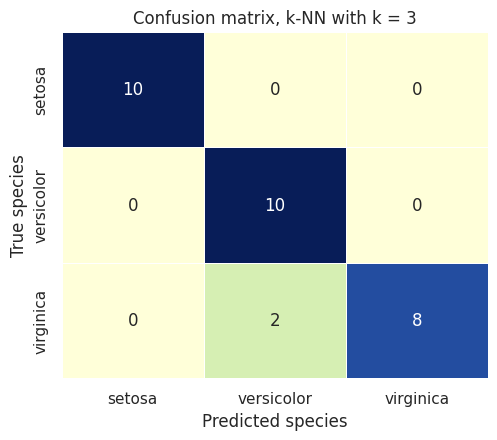

In [15]:
confusion = confusion_matrix(test_labels, knn_predictions)
print(confusion)

plt.figure(figsize=(5.5, 4.5))
sns.heatmap(
    confusion,
    annot=True,
    fmt="d",
    cmap="YlGnBu",
    cbar=False,
    linewidths=0.5,
    linecolor="white",
    xticklabels=species_names,
    yticklabels=species_names,
)
plt.xlabel("Predicted species")
plt.ylabel("True species")
plt.title("Confusion matrix, k-NN with k = 3")
plt.show()

### Checkpoint 3

**1. How many predictions were correct?**  
28 of 30 test flowers, which is an accuracy of 0.933 (93.3%).

**2. Which species were confused, if any?**  
Setosa: 10 of 10 correct. Versicolor: 10 of 10 correct. Virginica: 8 of 10, and the two missed
flowers were labelled versicolor. The error is one-directional and happens exactly in the pair
that overlapped in the scatter plot, so the matrix confirms what the data exploration suggested.

**3. Does high accuracy prove that the model will always be correct in the real world?**  
No. The score was measured on 30 flowers only, so one flower is worth 3.3% and the estimate is
very noisy. Iris is also a small, clean and perfectly balanced dataset collected under controlled
conditions. Real measurements are noisier, may come from other regions or other species, and the
score would drop. A good test score is evidence, not a proof.

**4. Why is it important that the testing flowers were not used during training?**  
k-NN stores its training examples, so a flower from the training set would find itself as its own
nearest neighbour and would almost always be classified correctly. The score would then describe
memorisation, not generalisation. Only unseen flowers can show whether the learned pattern
transfers to new data.

## 10. Required experiment — changing k

`k` decides how many neighbours are allowed to vote. I train the same model for
k = 1, 3, 5, 7, 9 on the same split and write down the accuracy of each one.

In [16]:
k_values = [1, 3, 5, 7, 9]
experiment_rows = []

for k in k_values:
    candidate = KNeighborsClassifier(n_neighbors=k)
    candidate.fit(train_scaled, train_labels)
    candidate_predictions = candidate.predict(test_scaled)

    candidate_accuracy = accuracy_score(test_labels, candidate_predictions)
    experiment_rows.append({
        "k": k,
        "accuracy": round(candidate_accuracy, 3),
        "correct of 30": int(np.sum(test_labels == candidate_predictions)),
    })

k_experiment = pd.DataFrame(experiment_rows)
display(k_experiment)

best_row = k_experiment.loc[k_experiment["accuracy"].idxmax()]
print("Highest accuracy in this run:", best_row["accuracy"], "at k =", int(best_row["k"]))

,k,accuracy,correct of 30
0,1,0.967,29
1,3,0.933,28
2,5,0.933,28
3,7,0.967,29
4,9,0.967,29


Highest accuracy in this run: 0.967 at k = 1


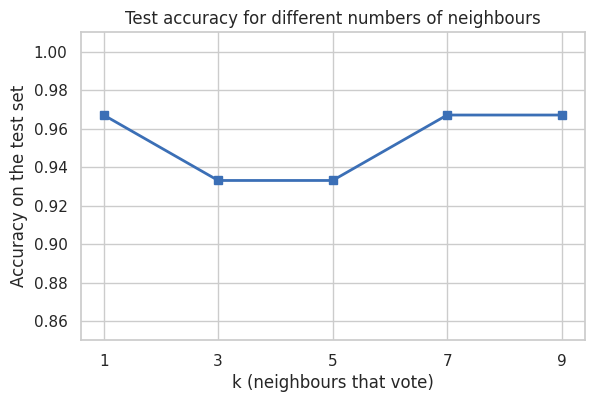

In [17]:
plt.figure(figsize=(6.5, 4))
plt.plot(k_experiment["k"], k_experiment["accuracy"],
         marker="s", linewidth=2, color="#3b6fb6")
plt.title("Test accuracy for different numbers of neighbours")
plt.xlabel("k (neighbours that vote)")
plt.ylabel("Accuracy on the test set")
plt.xticks(k_values)
plt.ylim(0.85, 1.01)
plt.show()

### My experiment answers

**1. Which value of k produced the highest test accuracy?**  
k = 1, k = 7 and k = 9 share the best result, 0.967 (29 of 30 correct). k = 3 and k = 5 give
0.933 (28 of 30).

**2. Did every value of k produce a different result?**  
No, only two different values appeared. The whole gap between the "best" and the "worst" setting is
a single test flower, because one flower is worth 1/30 = 3.3% here.

**3. Why is it unfair to claim that one setting is always best after testing only one small dataset?**  
The number 0.967 belongs to these 150 flowers and to this one split with `random_state=42`. With a
different seed the ranking of the k values changes, and on another dataset it changes again. A
difference of one example is far inside the noise of a 30-flower test set, so it cannot support a
general claim. It is also suspicious that k = 1 is among the winners: a model that trusts a single
neighbour normally overfits and follows the noise. To choose `k` honestly I would need
cross-validation (several splits averaged) and a separate validation set, so that the test set is
not used for tuning at all.

## 11. Optional comparison — a small neural network

A neural network is another classifier. Here I use the ready-made `MLPClassifier`; understanding
backpropagation is not required in this lesson.

The network consists of:

- four input values (one per measurement);
- one hidden layer with eight neurons;
- three outputs, one per species.

In [18]:
mlp_classifier = MLPClassifier(
    hidden_layer_sizes=(8,),
    max_iter=2000,
    random_state=SEED,
)
mlp_classifier.fit(train_scaled, train_labels)

mlp_predictions = mlp_classifier.predict(test_scaled)
mlp_accuracy = accuracy_score(test_labels, mlp_predictions)

comparison_table = pd.DataFrame({
    "Model": ["k-NN (k = 3)", "Neural network (8 hidden neurons)"],
    "Test accuracy": [knn_accuracy, mlp_accuracy],
    "Correct of 30": [hits, int(np.sum(test_labels == mlp_predictions))],
})
display(comparison_table.round(3))

print("Confusion matrix of the neural network:")
print(confusion_matrix(test_labels, mlp_predictions))

,Model,Test accuracy,Correct of 30
0,k-NN (k = 3),0.933,28
1,Neural network (8 hidden neurons),0.933,28


Confusion matrix of the neural network:
[[10  0  0]
 [ 0  9  1]
 [ 0  1  9]]


### Think carefully

**If the neural network had the higher accuracy, would it automatically be the better model? No.**

In this run both models reach the same 0.933, so the numbers give me no reason to prefer the
network at all. Even a small advantage would have to be judged against several other criteria:

- **Size of the difference.** One test flower is 3.3%. A gap of that size is noise, not evidence.
- **Dataset size.** 120 training flowers are far too few for a neural network to show its strength;
  its advantage appears on large and complex data.
- **Interpretability.** k-NN can justify an answer — "the closest known flowers were virginica".
  The network only offers weights, which is a real problem when decisions affect people.
- **Simplicity and cost.** The network needs an optimizer, 2000 iterations and a `random_state`;
  k-NN has one hyperparameter. k-NN, however, pays at prediction time and stores the whole dataset.

A more complicated model is not a better model just because it sounds more advanced.

## 12. Final reflection

**1. What was the AI task in this practical work?**  
Supervised classification: predict which of three Iris species a flower belongs to, using its four
measurements as input.

**2. What is the difference between a feature and a label?**  
A feature is an input the model is allowed to see, for example petal width. A label is the correct
output I want it to reproduce, that is the species. Features are known for every flower; labels are
known only for the training flowers and are hidden from the model at prediction time.

**3. What is the difference between training and prediction?**  
Training uses examples *together with* their labels to build the model. Prediction applies the
finished model to a flower whose label it does not receive. Training happens once, prediction can
be repeated on any new flower.

**4. Why did we keep a separate testing set?**  
To get an honest estimate of how the model behaves on data it has never seen. Measuring on the
training flowers would reward memorisation, and for k-NN that is almost free, since every training
flower is its own nearest neighbour.

**5. Explain k-NN using a simple real-life analogy.**  
I move into an unfamiliar street and want to know which rubbish-collection day applies to me. I ask
the three closest neighbours and follow the answer most of them give. k-NN does exactly this: it
looks for the most similar known cases and copies their majority answer.

**6. What does accuracy measure?**  
The proportion of predictions that were correct: correct answers divided by all answers. It treats
every mistake as equally bad and says nothing about which classes were confused.

**7. What information does a confusion matrix provide?**  
The full breakdown of answers: for every true species, how many flowers went to every predicted
species. It reveals the *direction* of the errors — here two virginica were called versicolor,
while no versicolor was called virginica — which a single accuracy number hides completely.

**8. Give one limitation of this experiment.**  
The test set contains only 30 flowers, so the resolution of the accuracy metric is 3.3% and the
estimate carries a wide uncertainty. In addition, `k` was chosen by looking at that same test set,
which is a mild form of tuning on the test data; cross-validation would be the correct approach.

**9. Give one responsible or ethical question that should be considered when AI is used for people
instead of flowers.**  
The cost of an error stops being symmetric. Mislabelling a flower harms nobody; a wrong decision in
credit scoring, hiring or medical triage takes a real opportunity away from a specific person. Two
consequences follow: the model reproduces the biases of its training data, so historical
discrimination becomes an automated rule, and a k-NN-style answer offers no explanation beyond
"similar people were treated this way" — while a person affected by the decision has a legitimate
right to an explanation and to appeal.

### Conclusion

In this work I completed a full supervised-learning cycle on the Iris dataset. I inspected 150
examples with four features, confirmed that the three species are balanced, and saw in the scatter
plots that setosa is clearly separable while versicolor and virginica overlap. I then split the data
80/20 with stratification, standardized the features using statistics learned from the training part
only, and trained a k-NN classifier. The model reached 93.3% accuracy, and the confusion matrix
showed that both errors were virginica flowers labelled versicolor — exactly the overlap I had
noticed earlier. Changing k moved the score by one single flower. The main lesson is that a score
measured on 30 examples is weak evidence, not a proof of intelligence or fairness.

## Key message from Lesson 1

An AI model learns patterns from examples. Its prediction depends on the data, the features, the
algorithm and the settings. A high score on a small test set is useful evidence, but it does not
prove that the model is intelligent, fair or always correct.